## Q.1. Modification of Line class ##

- You are given a class `Point` and `Line` (as discussed in class) to represent a line segment in the
$2D$ plane. Note that a Line object represents a line segment now, instead of an infinite line.
- You must use the given `Point` class and modify the given `Line` class.

In [1]:
# Use the Point class 

import math
import copy

class Point:

    """Represents a point in 2-D space.
        attributes: x and y for the coordinates
        methods: reset, scale, scaled, dist, collinear (static), translate, translated
    """

    def __init__(self, x=0, y=0):
        self.x = x
        self.y = y

    def __str__(self):
        return f'Point({self.x}, {self.y})'

    def reset(self):
        self.x = 0
        self.y = 0

    def scale(self,c):
        self.x = c * self.x
        self.y = c * self.y

    def scaled(self,c):
        return Point(c*self.x,c*self.y)

    def dist(self, p2=None):
        if p2 is None:
            p2=Point(0,0)
        dx = (self.x - p2.x)
        dy = (self.y - p2.y)
        dsq = dx**2 + dy**2
        return math.sqrt(dsq)

    @staticmethod
    def collinear(p1, p2, p3):
        return (p2.y - p1.y)*(p3.x - p1.x) == (p3.y - p1.y)*(p2.x - p1.x)

    def __add__(self,p):
        return(Point(self.x + p.x, self.y + p.y))

    def __sub__(self,p):
        return(Point(self.x - p.x, self.y - p.y))

    def __mul__(self,p):
        return(Point(self.x * p.x, self.y * p.y))

    def __matmul__(self,p):
        return(Point(self.x * p.x, self.y * p.y))

    def __lt__(self,p):
        return(self.x < p.x and self.y < p.y)

    def __gt__(self,p):
        return(self.x > p.x and self.y > p.y)

    def __le__(self,p):
        return(self.x <= p.x and self.y <= p.y)

    def __ge__(self,p):
        return(self.x >= p.x and self.y >= p.y)

    def __eq__(self, other):
        return (self.x == other.x) and (self.y == other.y)

    def __ne__(self,p):
        return(not(self == p))

    def translate(self,dx,dy):
        self.x += dx
        self.y += dy

    def translated(self, dx=0, dy=0):
        point = copy.copy(self)
        point.translate(dx, dy)
        return point

**You are required to add the following methods to the Line class.**
- Methods:
    - `midpoint()`
    Returns the midpoint of the line segment.
    - `contains point(p)`
    Takes a Point object $p$ and returns `True` if the point lies inside the line segment,
    otherwise `False`. You may use the `collinear` method to check if the endpoints of the
    line segment and $p$ are collinear. If so, you need to also check if the $x$ and $y$ coordinates
    of $p$ lies between those of the end points of the line.
    - `translate updown(dy)`
    Shifts the line segment by $dy$ in the $y$-direction.
    - `isParallel(l1, l2)` (static method)
    Takes two Line segment objects and checks if they are parallel each other. Note that
    two line segments are parallel if their slopes are equal.
    - `isPerp(l1, l2)` (static method)
    Takes two Line segment objects and checks they are perpendicular.
    (Hint: A line of slope $0$ is perpendicular to a line of slope None. In other cases, two
    lines are perpendicular if and only if the product of their slopes is −1)
    - `point of intersection()` (static method)
    Takes two Line objects $l_1$ and $l_2$ and returns `True` their unique point of intersection
    if they are non-parallel and intersect. Otherwise the method returns `None`. You need
    to make sure that the point of intersection lies within segments $l_1$ and $l_2$. You can
    find the point of intersection of two non-parallel lines $y = m_1x+c_1$ and $y = m_2x+c_2$
    using the following formulae: $x=\frac{c_2-c_1}{m_1-m_2}$ ; $y=\frac{m_1c_2-m_2c_1}{m_1-m_2}$

In [30]:
import matplotlib.pyplot as plt
class Line:

    """Represents a line passing through 2 points in 2-D space.
    """

    def __init__(self, p1, p2):
        if p1.x == p2.x and p1.y == p2.y:
            raise ValueError("Two distinct points are required to uniquely define a line")

        self.__p1 = Point(p1.x, p1.y)
        self.__p2 = Point(p2.x, p2.y)

        if p1.x == p2.x:
            self.__m = None
        else:
            self.__m = (p2.y - p1.y) / (p2.x - p1.x)

    def getSlope(self):
        if self.__m is not None:
            return round(self.__m,2)
        return None

    def isVertical(self):
        return self.__m is None

    def midpoint(self):
        mid_x=(self.__p1.x + self.__p2.x)/2
        mid_y=(self.__p1.y + self.__p2.y)/2
        return Point(mid_x,mid_y)
        
    def contains_point(self,p):
        if not Point.collinear(self.__p1,self.__p2,p):
            return False
        return (min(self.__p1.x,self.__p2.x)<=p.x<=max(self.__p1.x,self.__p2.x) and min(self.__p1.y,self.__p2.y)<=p.y<=max(self.__p1.y,self.__p2.y))

    def translate_updown(self,dy):
        self.__p1.translate(0,dy)
        self.__p2.translate(0,dy)

    @staticmethod
    def is_parallel(l1,l2):
        return l1.getSlope()==l2.getSlope()

    @staticmethod
    def is_perp(l1,l2):
        m1=l1.getSlope()
        m2=l2.getSlope()
        if m1 is None and m2==0:
            return True
        if m2 is None and m1==0:
            return True
        if m1 is None or m2 is None:
            return True
        else:
            return round(m1*m2,2) ==-1

    @staticmethod
    def point_of_intersection(l1,l2):
        m1=l1.getSlope()
        m2=l2.getSlope()
        if Line.is_parallel(l1,l2):
            return False
        p1,p2=l1._Line__p1, l1._Line__p2
        p3,p4=l2._Line__p1, l2._Line__p2
        if m1 is None:
            x=p1.x
            c2=p3.y-m2*p3.x
            y=m2*x+c2
        elif m2 is None:
            x=p3.x
            c1=p1.y-m1*p1.x
            y=m1*x+c1
        else:
            c1=p1.y-m1*p1.x
            c2=p3.y-m2*p3.x
            x=(c2-c1)/(m1-m2)
            y=(m1*c2-m2*c1)/(m1-m2)
        com=Point(x,y)
        if l1.contains_point(com) and l2.contains_point(com):
            return com
        return None
            
    def __str__(self):
        if self.__m is None:
            return f"Line: x = {self.__p1.x}"
        return f"Line: y - {self.__p1.y} = {self.__m:.2f}(x - {self.__p1.x})"

    def draw(self,color="green",label=None):
        x = [self.__p1.x, self.__p2.x]
        y = [self.__p1.y, self.__p2.y]
        plt.plot(x, y, marker='o',color=color,label=label)

- Write a main program to test all the above methods and show the effect using plots.

Line L1:Line: y - 3 = 1.00(x - 1) and two end points Point(1, 3) and Point(4, 6)
Line L1:Line: y - 6 = 2.00(x - 5) and two end points Point(5, 6) and Point(3, 2)
Midpoint of l2: Point(3.0, 4.0)
Point lies on l1: False
Parallel: False
Perpendicular: False
Line l1 and l2 intersected at : Point(2.0, 5.0)


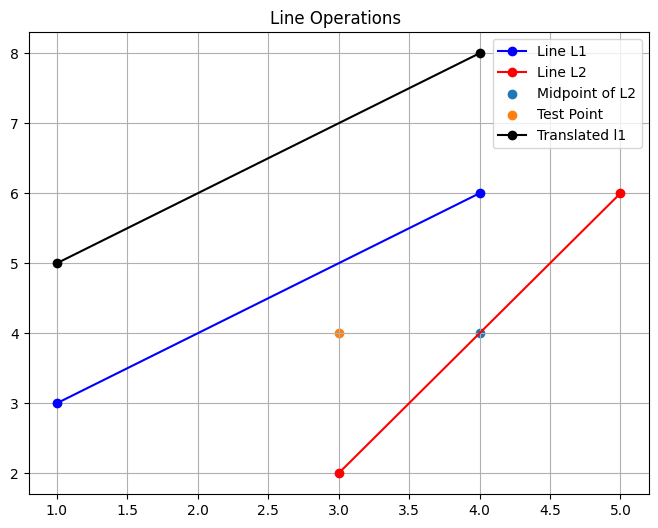

In [36]:
p1 = Point(1, 3)
p2 = Point(4, 6)
p3 = Point(5, 6)
p4 = Point(3, 2)

l1 = Line(p1, p2)
l2 = Line(p3, p4)
## The lines 
print(f"Line L1:{l1} and two end points {p1} and {p2}")
print(f"Line L1:{l2} and two end points {p3} and {p4}")
plt.figure(figsize=(8,6))

# Draw lines with names
l1.draw(color='blue', label='Line L1')
l2.draw(color='red', label='Line L2')

# Midpoint
mid = l2.midpoint()
print("Midpoint of l2:",mid2)
plt.scatter(mid.x, mid.y, label='Midpoint of L2')

# Test point
test_point = Point(3, 4)
print("Point lies on l1:", l1.contains_point(test_point))
plt.scatter(test_point.x, test_point.y, label='Test Point')

# Translated line
l3 = Line(p1, p2)
l3.translate_updown(2)
l3.draw(color='black', label='Translated l1')

# Parallel 
print("Parallel:", Line.is_parallel(l1, l2))

# Perpendicular
print("Perpendicular:", Line.is_perp(l1, l2))

# Intersection
inter = Line.point_of_intersection(l1, l2)
print("Line l1 and l2 intersected at :", common)
if inter:
    plt.scatter(inter.x, inter.y, label='Intersection')

plt.legend()
plt.title("Line Operations ")
plt.grid()
plt.show()


## Q.2. Operations on Circle 

- Define a class `Circle` with the following specifications.
- Attributes:
     - `center`: a Point object representing the center of the circle
     - `radius`: a positive real number
- Methods:
     - `area()`
    Returns the area of the circle.
     - `perimeter()`
    Returns the circumference of the circle.
     - `contains point(p)`
    Takes a Point object $p$ and returns `True` if the point lies inside or on the circle,
    otherwise `False`.
     - `translate(dx, dy)`
    Shifts the circle by $dx$ in the $x$-direction and $dy$ in the $y$-direction.
     - `scale(factor)`
    Scales the circle by a given positive factor. The radius is multiplied by the factor
    while the center remains unchanged. If factor $\le 0$, handle it appropriately.
     - `intersects()` (Static Method)
    Takes another Circle object other and returns True if the two circles intersect or
    touch, otherwise False.

In [59]:
import math
import matplotlib.pyplot as plt

class Circle:
    def __init__(self, center, radius):
        if radius <= 0:
            raise ValueError("Radius must be positive")
        self.center = Point(center.x, center.y)
        self.radius = radius

    def __str__(self):
        return f"Circle(center={self.center}, radius={self.radius})"

    def area(self):
        return math.pi * self.radius ** 2

    def perimeter(self):
        return 2 * math.pi * self.radius

    def contains_point(self, p):
        return self.center.dist(p) <= self.radius

    def translate(self, dx, dy):
        self.center.translate(dx, dy)

    def scale(self, factor):
        if factor <= 0:
            raise ValueError("Scaling factor must be positive")
        self.radius *= factor

    @staticmethod
    def intersects(c1, c2):
        d = c1.center.dist(c2.center)
        return d <= (c1.radius + c2.radius)

    def draw(self, color='blue', label=None):
        circle = plt.Circle((self.center.x, self.center.y),self.radius,fill=False,color=color,label=label)
        plt.gca().add_patch(circle)
        plt.axis("equal")
        plt.scatter(self.center.x, self.center.y)

- Write a main program to test all the above methods and show the effect using plots.

Area of C1: 28.274333882308138
Perimeter of C1: 18.84955592153876
Point inside C1: True
C1 intersects C2: True


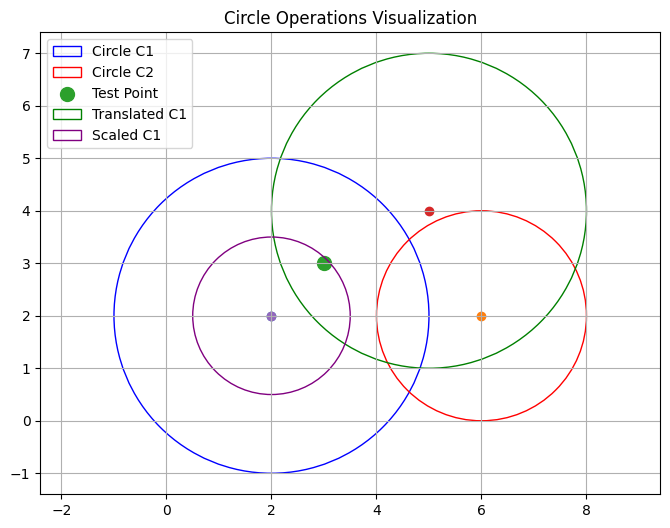

In [60]:
c1 = Circle(Point(2, 2), 3)
c2 = Circle(Point(6, 2), 2)
plt.figure(figsize=(8,6))

# Draw circles
c1.draw(color='blue', label='Circle C1')
c2.draw(color='red', label='Circle C2')

# Area & Perimeter 
print("Area of C1:", c1.area())
print("Perimeter of C1:", c1.perimeter())

# Point Containment 
p = Point(3, 3)
print("Point inside C1:", c1.contains_point(p))
plt.scatter(p.x, p.y, label='Test Point', s=100)

# Translate 
c3 = Circle(Point(2, 2), 3)
c3.translate(3, 2)
c3.draw(color='green', label='Translated C1')

# Scale 
c4 = Circle(Point(2, 2), 3)
c4.scale(0.5)
c4.draw(color='purple', label='Scaled C1')

# Intersection 
print("C1 intersects C2:", Circle.intersects(c1, c2))

# Main Plot
plt.legend()
plt.title("Circle Operations Visualization")
plt.axis('equal')  
plt.grid()
plt.show()
